In [1]:
from google.colab import userdata
GIT_TOKEN = userdata.get('GITHUB_TOKEN')

In [ ]:
# Clone and install this project, then clone/install LibreYOLO as the detector package.
import os
from pathlib import Path

GIT_USERNAME = "bencejdanko"
GIT_REPO = f"github.com/{GIT_USERNAME}/Overhead-People-Counting-YOLOv8n-FOMO-Ethos-U55-NPU.git"
PROJECT_DIR = Path("/content/Overhead-People-Counting-YOLOv8n-FOMO-Ethos-U55-NPU")

if not PROJECT_DIR.exists():
    !git clone https://{GIT_REPO} {PROJECT_DIR}

%cd /content/Overhead-People-Counting-YOLOv8n-FOMO-Ethos-U55-NPU
!git pull
!pip install -e .

# Re-clone LibreYOLO if missing or incomplete.
if not Path("libreyolo/pyproject.toml").exists():
    !rm -rf libreyolo
    !git clone https://github.com/LibreYOLO/libreyolo.git

!pip install -e ./libreyolo

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from pathlib import Path

from yolo_core.pipeline import YoloDetectionAnnotator, export_hf_dataset_specs_to_yolo
from yolo_core.model import train_libreyolo_model, export_libreyolo_onnx
from yolo_core.quantization import (
    convert_onnx_to_tflite_with_onnx2tf,
    compile_tflite_with_vela,
)


In [5]:
# 1. Dataset Setup
repo_ids = [
    "bdanko/overhead-people-rgb",
    # "bdanko/loaf_resolution_512",
]

class_names = ["person"]
category_id_to_class_id = {1: 0}
loaf_center_crop_size = 192
center_crop_sizes = {
    "bdanko/loaf_resolution_512": loaf_center_crop_size,
}

train_datasets = []
val_datasets = []
test_datasets = []

for repo_id in repo_ids:
    dataset = load_dataset(repo_id)
    train_split = dataset["train"]
    split = train_split.train_test_split(test_size=0.2, seed=15179996)
    val_test = split["test"].train_test_split(test_size=0.5, seed=15179996)

    train_datasets.append((repo_id, split["train"]))
    val_datasets.append((repo_id, val_test["train"]))
    test_datasets.append((repo_id, val_test["test"]))

annotator = YoloDetectionAnnotator(
    class_names=class_names,
    category_id_to_class_id=category_id_to_class_id,
    merge_all_categories=False,
)


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

In [6]:
# 2. Export Hugging Face datasets to YOLO format, or reuse an existing export
yolo_data_dir = Path("./yolo_dataset")
data_yaml = yolo_data_dir / "data.yaml"

expected_pairs = [
    ("train", train_datasets),
    ("validation", val_datasets),
    ("test", test_datasets),
]

def count_files(path, suffixes):
    if not path.exists():
        return 0
    return sum(
        1
        for item in path.iterdir()
        if item.is_file() and item.suffix.lower() in suffixes
    )

def yolo_export_is_complete():
    if not data_yaml.exists():
        return False

    for split_name, dataset_specs in expected_pairs:
        expected_count = sum(len(dataset) for _, dataset in dataset_specs)
        image_count = count_files(
            yolo_data_dir / split_name / "images",
            {".jpg", ".jpeg", ".png"},
        )
        label_count = count_files(
            yolo_data_dir / split_name / "labels",
            {".txt"},
        )

        print(
            f"{split_name}: expected={expected_count}, "
            f"images={image_count}, labels={label_count}"
        )

        if image_count != expected_count or label_count != expected_count:
            return False

    return True

if yolo_export_is_complete():
    print(f"Reusing existing YOLO export: {data_yaml}")
    dataset_stats = {
        split_name: {
            "images": count_files(yolo_data_dir / split_name / "images", {".jpg", ".jpeg", ".png"}),
            "labels": count_files(yolo_data_dir / split_name / "labels", {".txt"}),
        }
        for split_name, _ in expected_pairs
    }
else:
    print("YOLO export missing or incomplete. Rebuilding...")
    data_yaml, dataset_stats = export_hf_dataset_specs_to_yolo(
        {
            "train": train_datasets,
            "validation": val_datasets,
            "test": test_datasets,
        },
        yolo_data_dir,
        annotator,
        center_crop_sizes=center_crop_sizes,
        overwrite=True,
    )

print(data_yaml)
dataset_stats

YOLO export missing or incomplete. Rebuilding...
yolo_dataset/data.yaml


{'train': {'images': 6846, 'boxes': 14469},
 'validation': {'images': 856, 'boxes': 1833},
 'test': {'images': 856, 'boxes': 1796}}

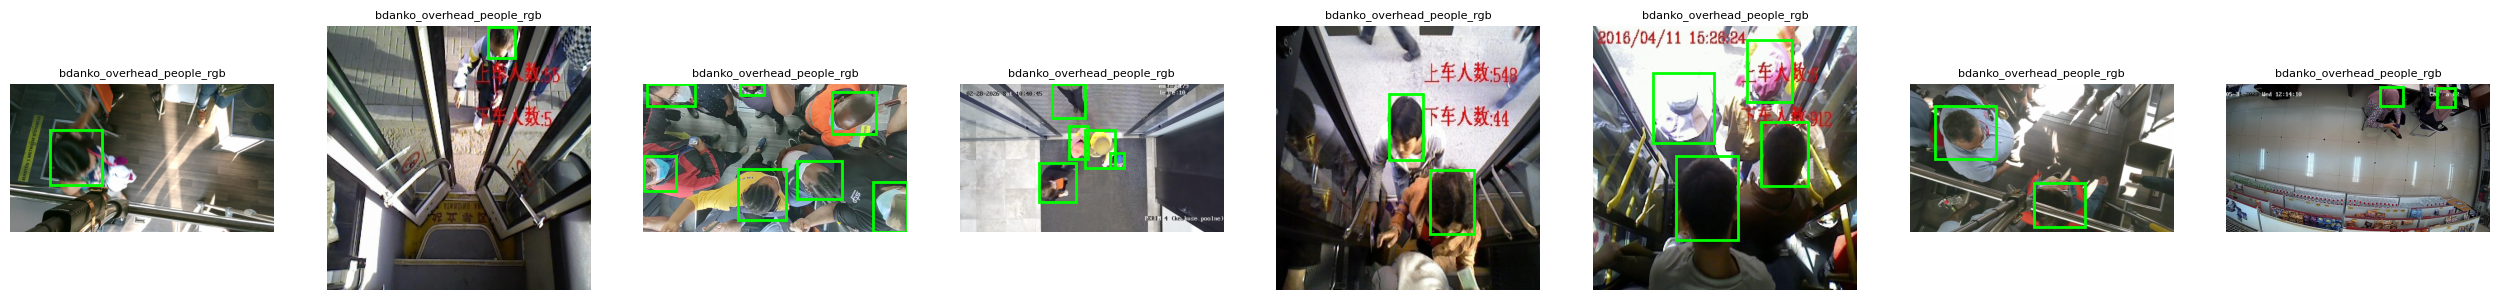

In [7]:
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

image_dir = yolo_data_dir / "train" / "images"
label_dir = yolo_data_dir / "train" / "labels"

images_by_source = defaultdict(list)
for image_path in image_dir.iterdir():
    if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
        source = image_path.name.rsplit("_", 1)[0]
        images_by_source[source].append(image_path)

rng = np.random.default_rng(15179996)
per_source = 8
sample_images = []

for source, paths in images_by_source.items():
    count = min(per_source, len(paths))
    indices = rng.choice(len(paths), size=count, replace=False)
    sample_images.extend(paths[i] for i in indices)

fig, axes = plt.subplots(
    1,
    len(sample_images),
    figsize=(4 * len(sample_images), 4),
    squeeze=False,
)

for ax, image_path in zip(axes[0], sample_images):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(image_path.name.rsplit("_", 1)[0], fontsize=8)

    label_path = label_dir / f"{image_path.stem}.txt"
    for line in label_path.read_text().splitlines():
        class_id, x, y, w, h = map(float, line.split())
        x0 = (x - w / 2) * width
        y0 = (y - h / 2) * height
        ax.add_patch(
            plt.Rectangle(
                (x0, y0),
                w * width,
                h * height,
                fill=False,
                color="lime",
                linewidth=2,
            )
        )

plt.show()

In [11]:
# 4. Train LibreYOLO nano detector
model_ref = "LibreYOLOXn.pt"
size = "n"
imgsz = 192

# keep this lower
# lower batches converge more nicely
batch_size = 16

epochs = 30

model, train_results = train_libreyolo_model(
    data_yaml=data_yaml,
    model_ref=model_ref,
    size=size,
    epochs=epochs,
    batch=batch_size,
    imgsz=imgsz,
    project="runs/yolo_train",
    name="libreyolo_nano_people",
    device="cuda:0",
    workers=4,
    lr0=0.01,
    relu6=True,
)

train_results


Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=4.09s).
Accumulating evaluation results...
DONE (t=0.62s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.443
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.864
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.396
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.244
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.376
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.470
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.252
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.531
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.566
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.414
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100

{'final_loss': 2.582432409502425,
 'epoch_losses': [8.999933476717967,
  5.680394460570137,
  5.186653636536509,
  5.007163101772092,
  5.0752728930059465,
  4.951356959792803,
  4.786218782640853,
  4.666511886524704,
  4.579686619200796,
  4.456285616136947,
  4.362267863075688,
  4.298823491582331,
  4.211303276835747,
  4.183131957953831,
  4.18610057515918,
  3.3064865683609583,
  3.1154631128850974,
  3.029517749570451,
  2.971196122889249,
  2.921720862388611,
  2.877550829131648,
  2.8392088593177074,
  2.7935816611883775,
  2.7578856697622336,
  2.737001785692179,
  2.6947102186814793,
  2.672983725115938,
  2.632694275874012,
  2.598787507920895,
  2.582432409502425],
 'epoch_lrs': [{'group0': 0.0004000000000000001,
   'group1': 0.0004000000000000001,
   'group2': 0.0004000000000000001},
  {'group0': 0.0016000000000000003,
   'group1': 0.0016000000000000003,
   'group2': 0.0016000000000000003},
  {'group0': 0.0036, 'group1': 0.0036, 'group2': 0.0036},
  {'group0': 0.006400000

In [26]:
# 5. Export ONNX
onnx_path = export_libreyolo_onnx(
    model,
    imgsz=imgsz,
    opset=11,
    output_dir="runs/yolo_train/libreyolo_nano_people/exports",
    simplify=False,
)

onnx_path


PosixPath('runs/yolo_train/libreyolo_nano_people/exports/yolox_n.onnx')

In [27]:
import numpy as np
from PIL import Image
from pathlib import Path

calib_paths = list((yolo_data_dir / "train" / "images").glob("*.jpg"))[:100]

calib = []
for path in calib_paths:
    img = Image.open(path).convert("RGB").resize((192, 192))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    arr = (arr - np.array([0.485, 0.456, 0.406], dtype=np.float32)) / np.array([0.229, 0.224, 0.225], dtype=np.float32)
    calib.append(arr)

calib = np.stack(calib, axis=0).astype(np.float32)
np.save("yolox_calib_images.npy", calib)

calib.shape, calib.dtype

((100, 192, 192, 3), dtype('float32'))

In [28]:
!rm -rf tflite_output_int8
!onnx2tf \
  -i runs/yolo_train/libreyolo_nano_people/exports/yolox_n.onnx \
  -o tflite_output_int8 \
  -oiqt \
  -cind images yolox_calib_images.npy "[[[[0.485,0.456,0.406]]]]" "[[[[0.229,0.224,0.225]]]]"

Streaming output truncated to the last 5000 lines.
│ Resize     │ 2              │ 2                │
│ Shape      │ 15             │ 3                │
│ Sigmoid    │ 110            │ 110              │
│ Slice      │ 15             │ 13               │
│ Transpose  │ 3              │ 3                │
│ Unsqueeze  │ 9              │ 3                │
│ Model Size │ 3.5MiB         │ 3.5MiB           │
└────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add        │ 10             │ 10               │
│ Concat     │ 24             │ 24               │
│ Constant   │ 249            │ 249              │
│ Conv       │ 113            │ 113              │
│ Exp        │ 3              │ 3                │
│ Gather     │ 3              │ 3                │
│ MaxPool    │ 3              │ 3 

In [ ]:
!vela /content/Overhead-People-Counting-YOLOv8n-FOMO-Ethos-U55-NPU/tflite_output_int8/yolox_n_full_integer_quant.tflite \
  --accelerator-config ethos-u55-256 \
  --config /content/Overhead-People-Counting-YOLOv8n-FOMO-Ethos-U55-NPU/configs/default_vela.ini \
  --system-config Ethos_U55_High_End_Embedded \
  --memory-mode Shared_Sram \
  --output-dir vela_output